# Graph Neural Networks

## Graph-Structured Data
### Introduction
* A dataset represented with nodes (vertices) and edges
    * The nodes represent entities/objects and the edges represent relationships
* Graphs have no fixed grid or order
    * This is compared to images or sequenced data

### Characteristics of Graph-Structured Data
* Irregular structure, no fixed shape
* Different nodes can have different numbers of neighbors
* Primary information is depicted in the relationships (edges)

### Applications of Graph-Structured Data
* Social Networks
    * Real-life relationships or social media relationships
* Transportation
    * Roads, Airlines, Public Transit
* Scientific Applications
    * Protein interactions, Gene networks, Neural connectomes, Molecules, Crystal lattices
* Computer Systems
    * Security and Communication Graphs, File System Graphs
* Recommender Systems


## Graph Neural Networks (GNNs)

### Introduction
* Deep learning architecture designed to work on graph-structured data
* Designed to handle irregular, relational data
    * Data that is not organized on a grid or in a sequence but that represents interacting systems
* The nodes and edges have features (information) that provide more than just relationships
 
### Message Passing 
* Base of GNNs
1. Each node starts with features
2. Nodes send messages to neighbors, collect information from adjacent nodes (sometimes edges)
3. Aggregate neighbor information
4. Update node representations (combined node's current state with the aggregate neighbor information)
5. Repeat for multiple layers
    * After k layers, a node has information from nodes up to k "jumps" away.
    
## GNN Tasks/Outputs
* Node-level outputs
    * Node classification
        * Fraud detection: nodes are bank accounts, edges are money transfers
    * Node regression
        * Predict a property of a node
        * House price prediction: nodes are houses, edges are geographic proximity
* Edge-level Outputs
    * Link prediction
        * Friend recommendations: nodes are users, edges are existing friendships
    * Edge classification
        * Relationship type classification: nodes are people, edges are interactions between people
* Graph-level Outputs
    * Property prediction
        * Molecular property predictions: nodes are atoms, edges are chemical bonds
    * Whole-graph classification
        * Email network classification: nodes are email accounts, edges are emails sent

### Common GNN Variants and Applications
* Graph Convolutional Network (GCN)
    * A GCN smooths features over the graph in a set, learnable way
    * Example: Classify papers into research area
* Graph Sample and Aggregate (GraphSAGE)
    * Samples a fixed number of neighbors and aggregates their features
    * Computation bounded, scales to very large graphs
    * Example: Social media network recommendations
* Graph Attention Network
    * Compute attention weights over neighbors, different neighbors contribute differently
    * Learns which connections are more informative
    * Example: Fraud detection in transaction networks (certain transfers deserve higher atention)
* Message Passing Neural Network

### GNN Limitations

## Graph Neural Network Code in PyTorch

### Example Dataset: Cora
* Classic benchmark dataset for graph neural networks -- node classification
* The data set contains information on academic papers
    * Each node is a single paper (2,708 papers)
        * Features: A bag-of-word representations of ~1,433 words (binary vector)
        * Labels: Research topic (7 classes)
    * An edge represents that paper A cites paper B (5,429 citations)


In [ ]:
##################
## INSTALLATION ##
##################
# Adjust or comment out as needed. PyTorch Geometric is a popular library for graph neural networks and it also provides access to the Cora dataset.
!pip3 install torch_geometric

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.4 MB/s  0:00:00

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [ ]:
#############
## IMPORTS ##
#############
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

(np.float64(-1.161411619421523),
 np.float64(1.1554897906666493),
 np.float64(-1.1616997090494365),
 np.float64(1.2054103795929327))

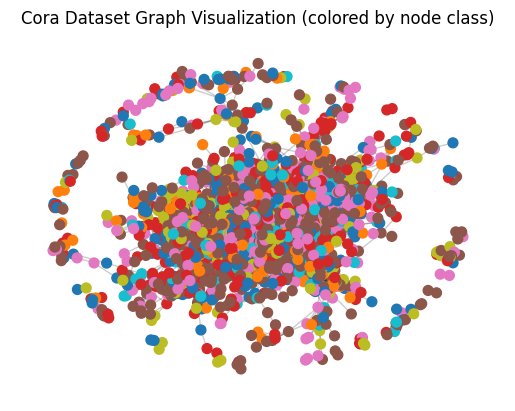

In [ ]:
##############################
## VISUALIZE ENTIRE DATASET ##
##############################
# Don't worry about the visualization code too 
# much. The key part is that we load the Cora 
# dataset and then visualize it as a graph, 
# coloring nodes by their class labels. This helps 
# us understand the structure of the dataset 
# before we apply any GNN models to it.

# Load Cora dataset from PyTorch Geometric
dataset = Planetoid(root='data/Cora', name='Cora')
data = dataset[0]

# Print basic dataset information
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of node features: {data.num_node_features}")
print(f"Number of classes: {dataset.num_classes}")

# Convert edge_index to NetworkX graph. This assumes edge_index is in COO format (shape [2, num_edges]) and is needed for visualization with NetworkX.
edge_index = data.edge_index.numpy()
G = nx.Graph()
G.add_edges_from(edge_index.T)  # edge_index shape: [2, num_edges]

# Node labels for coloring
labels = data.y.numpy()

# Use a layout for visualization. The spring layout is a common choice for general graph visualization because it tries to position nodes in a way that minimizes edge crossings and distributes them evenly.
pos = nx.spring_layout(G, seed=42)  # 2D layout

# Draw nodes with class-based colors
nx.draw_networkx_nodes(G, pos, node_size=50, node_color=labels, cmap=plt.cm.tab10)
nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.title("Cora Dataset Graph Visualization (colored by node class)")
plt.axis('off')


(np.float64(-1.0186779959169814),
 np.float64(1.1918200810599848),
 np.float64(-1.159933450070592),
 np.float64(1.07830686096464))

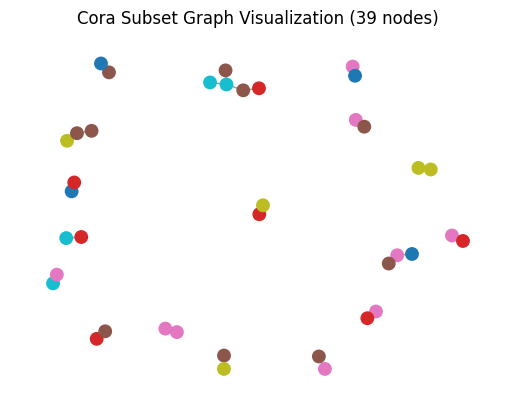

In [ ]:
#######################################
## VISUALIZE A SUBSET OF THE DATASET ##
#######################################

# Select a random subset of nodes
num_nodes_subset = 200
subset_nodes = np.random.choice(data.num_nodes, num_nodes_subset, replace=False)

# Create a mask for edges connecting nodes in the subset
edge_index = data.edge_index.numpy()
mask = np.isin(edge_index[0], subset_nodes) & np.isin(edge_index[1], subset_nodes)
subset_edges = edge_index[:, mask]

# Keep only nodes that actually appear in the edges
nodes_in_edges = np.unique(subset_edges)
node_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(nodes_in_edges)}
subset_edges_mapped = np.vectorize(node_mapping.get)(subset_edges)

# Build NetworkX graph
G = nx.Graph()
G.add_edges_from(subset_edges_mapped.T)

# Node labels for coloring (only nodes in edges)
labels = data.y[nodes_in_edges].numpy()

# Layout
pos = nx.spring_layout(G, seed=42)

# Plot
nx.draw_networkx_nodes(G, pos, node_size=80, node_color=labels, cmap=plt.cm.tab10)
nx.draw_networkx_edges(G, pos, alpha=0.4)
plt.title(f"Cora Subset Graph Visualization ({len(nodes_in_edges)} nodes)")
plt.axis('off')

# Note that when we select a random subset of 
# nodes we see that many of the "chains" of nodes 
# are quite short. This is because the Cora 
# dataset has a lot of nodes with low degree (many 
# nodes are only connected to a few others), so 
# when we randomly sample nodes, we often end up 
# with small disconnected components. This is a 
# common characteristic of real-world graph 
# datasets, where many nodes have few connections 
# and a few nodes have many connections (a 
# power-law degree distribution).



(np.float64(-1.1524853302844995),
 np.float64(1.1361900136283452),
 np.float64(-1.0455071349813791),
 np.float64(1.1943694562651987))

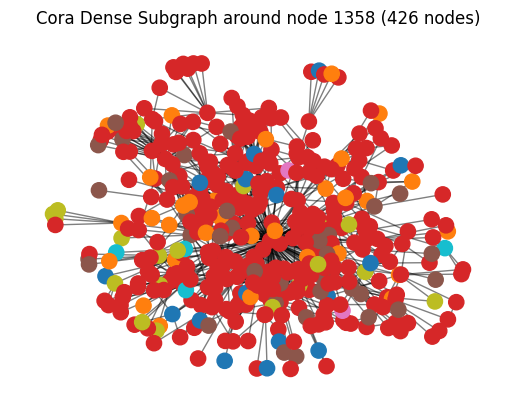

In [16]:
#########################################
## VISUALIZE A MORE CONNECTED SUBGRAPH ##
#########################################

# Pick a “seed” node with many neighbors
degrees = np.bincount(data.edge_index[0].numpy())
seed_node = np.argmax(degrees)  # node with highest degree

# Get the neighbors of the seed node (1-hop neighbors) and the neighbors of those neighbors (2-hop neighbors)
neighbors_1 = data.edge_index[1][data.edge_index[0] == seed_node].numpy()
neighbors_2 = []
for n in neighbors_1:
    neighbors_2.extend(data.edge_index[1][data.edge_index[0] == n].numpy())
neighbors_2 = np.array(neighbors_2)

# Combine nodes and keep unique
subset_nodes = np.unique(np.concatenate(([seed_node], neighbors_1, neighbors_2)))

# Filter edges connecting nodes in subset
edge_index = data.edge_index.numpy()
mask = np.isin(edge_index[0], subset_nodes) & np.isin(edge_index[1], subset_nodes)
subset_edges = edge_index[:, mask]

# Map old indices to consecutive integers
nodes_in_edges = np.unique(subset_edges)
node_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(nodes_in_edges)}
subset_edges_mapped = np.vectorize(node_mapping.get)(subset_edges)

# Build NetworkX graph
G = nx.Graph()
G.add_edges_from(subset_edges_mapped.T)

# Node labels for coloring
labels = data.y[nodes_in_edges].numpy()

# Layout
pos = nx.spring_layout(G, seed=42)

# Plot
nx.draw_networkx_nodes(G, pos, node_size=120, node_color=labels, cmap=plt.cm.tab10)
nx.draw_networkx_edges(G, pos, alpha=0.5)
plt.title(f"Cora Dense Subgraph around node {seed_node} ({len(nodes_in_edges)} nodes)")
plt.axis('off')


In [17]:
#######################################
## DEFINE GRAPH NEURAL NETWORK MODEL ##
#######################################

# Define the graph neural network to classify nodes in the Cora dataset. We will use a simple 2-layer 
# Graph Convolutional Network (GCN) for this task. The GCN will take the node features and the graph 
# structure (edges) as input and output class probabilities for each node. A GCN was chosen here 
# because it is a widely used and well-understood architecture for node classification tasks on graph 
# data, making it a good starting point for learning about GNNs. It effectively captures local graph 
# structure and node feature information, which is essential for classifying nodes based on their 
# attributes and their neighbors in the graph.

# Define a simple 2-layer GCN. The first layer transforms the input features to a hidden representation, and the second layer transforms the hidden representation to the output class probabilities. We also apply ReLU activation and dropout for regularization between the layers. The final output is passed through a log softmax function to get log probabilities for each class, which is suitable for use with the negative log likelihood loss during training. Note that a two-layer GCN is a common choice for node classification tasks, as it allows the model to capture information from both immediate neighbors (1-hop) and neighbors of neighbors (2-hop), which often provides enough context for accurate classification without being too complex. You can experiment with deeper GCNs or otehr types of GNNs as well.
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        """
        Inputs:
            in_channels: Number of input features per node (e.g., 1433 for Cora)
            hidden_channels: Number of hidden units in the first GCN layer 
            out_channels: Number of output classes (e.g., 7 for Cora)
        Outputs:
            None.
        Initializes a 2-layer GCN model with specified input, hidden, and output dimensions.
        """
        # Initialize the parent class
        super(GCN, self).__init__()
        # Define the first GCN layer that takes in the input features and outputs hidden representations
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # Define the second GCN layer that takes in the hidden representations and outputs class probabilities
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        """
        Inputs:
            x: Node feature matrix of shape [num_nodes, in_channels]
            edge_index: Edge index tensor of shape [2, num_edges] representing the graph structure
        Outputs:
            Log probabilities for each class for each node, of shape [num_nodes, out_channels]
        Defines the forward pass of the GCN model. It applies two graph convolutional layers with ReLU activation and dropout in between, and returns log probabilities for each class for each node.
        """
        # First layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        # Dropout for regularization
        x = F.dropout(x, p=0.5, training=self.training)
        # Second layer
        x = self.conv2(x, edge_index)
        # Output with log softmax for class probabilities
        return F.log_softmax(x, dim=1)


In [19]:
##############################
## TRAIN AND TEST THE MODEL ##
##############################

def train(model, optimizer):
    """
    Inputs:
        model: The GCN model to be trained
        optimizer: The optimizer used for training (e.g., Adam)
    Outputs:
        loss.item(): The training loss for the current epoch
    Trains the GCN model for one epoch using the provided optimizer and returns the training loss.
    """
    # Put the model in training mode. 
    model.train()
    # Zero the gradients before backpropagation
    optimizer.zero_grad()
    # Forward pass: compute the output of the model given the input features and edge index
    out = model(data.x, data.edge_index)
    # Compute the loss using negative log likelihood loss, only on the training nodes (masked by train_mask). This is done because we only want to compute the loss on the nodes that are part of the training set, as indicated by the train_mask. The model will learn to classify these nodes correctly, and we will evaluate its performance on the validation and test sets separately.
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    # Backpropagation: compute gradients and update model parameters
    loss.backward()
    # Update the model parameters using the optimizer
    optimizer.step()
    # Return the loss value for this epoch
    return loss.item()

def test(model):
    """
    Inputs:
        model: The GCN model to be evaluated
    Outputs:
        accs: A list containing the accuracy on the training, validation, and test sets [train_acc, val_acc, test_acc]
    Evaluates the GCN model on the training, validation, and test sets and returns the accuracies for each set.
    """
    # Place the model in evaluation mode.
    model.eval()
    # Compute the output of the model given the input features and edge index
    out = model(data.x, data.edge_index)
    # Get the predicted class for each node by taking the argmax of the output probabilities
    pred = out.argmax(dim=1)
    # Calculate accuracy for training, validation, and test sets using the respective masks. The accuracy is computed by comparing the predicted labels with the true labels (data.y) for the nodes that are part of each set (as indicated by the masks). We sum the number of correct predictions and divide by the total number of nodes in that set to get the accuracy.
    accs = []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        correct = pred[mask].eq(data.y[mask]).sum().item()
        acc = correct / mask.sum().item()
        accs.append(acc)
    return accs  # [train_acc, val_acc, test_acc]


In [23]:
##############################
## TRAIN AND TEST THE MODEL ##
##############################

# Initialize the GCN model. Here we are using 16 hidden units in the first layer, but adjust
# this as you desire.
model = GCN(in_channels=dataset.num_node_features, 
            hidden_channels=16, 
            out_channels=dataset.num_classes)

# Define the optimizer. We are using Adam with a learning rate of 0.01 and weight decay for 
# regularization. Adjust these hyperparameters as needed for better performance. The weight decay is 
# a form of L2 regularization that helps prevent overfitting by penalizing large weights in the 
# model. You can experiment with different learning rates and weight decay values to see how they 
# affect the training process and the final accuracy on the validation and test sets.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Train the model and print the loss and accuracies every 20 epochs. We train for a total of 200 epochs. You can adjust the number of epochs based on the convergence of the model and the performance on the validation set. Printing the loss and accuracies every 20 epochs allows us to monitor the training process and see how the model is improving over time.
for epoch in range(1, 201):
    loss = train(model, optimizer)
    if epoch % 20 == 0:
        train_acc, val_acc, test_acc = test(model)
        print("Epoch:", epoch, "Loss:", loss, 
              "Train:", train_acc*100, "% Val:", val_acc*100, "% Test:", test_acc*100, "%")

Epoch: 20 Loss: 0.2383897751569748 Train: 100.0 % Val: 77.2 % Test: 79.4 %
Epoch: 40 Loss: 0.05083731189370155 Train: 100.0 % Val: 77.0 % Test: 79.10000000000001 %
Epoch: 60 Loss: 0.051589176058769226 Train: 100.0 % Val: 76.8 % Test: 78.8 %
Epoch: 80 Loss: 0.04023677855730057 Train: 100.0 % Val: 77.2 % Test: 79.9 %
Epoch: 100 Loss: 0.03953199461102486 Train: 100.0 % Val: 75.6 % Test: 80.0 %
Epoch: 120 Loss: 0.052977900952100754 Train: 100.0 % Val: 76.8 % Test: 80.30000000000001 %
Epoch: 140 Loss: 0.03446068614721298 Train: 100.0 % Val: 76.8 % Test: 80.7 %
Epoch: 160 Loss: 0.03653770312666893 Train: 100.0 % Val: 76.6 % Test: 80.0 %
Epoch: 180 Loss: 0.01806429773569107 Train: 100.0 % Val: 76.6 % Test: 80.5 %
Epoch: 200 Loss: 0.02423393353819847 Train: 100.0 % Val: 78.0 % Test: 81.2 %
